# Поиск лучшего LLM prompt для классификации ручного датасета

Главная метрика этого notebook: `primary_class_supported_macro_f1`.

Почему именно она:
- каждая новость получает один главный класс;
- классы: `not_relevant` + 36 социальных факторов;
- если LLM не вернула релевантные факторы, это `not_relevant`;
- если вернула факторы, главный predicted class = фактор с максимальной `relevance`;
- supported macro-F1 усредняет качество только по классам, которые реально есть в eval split;
- классы с нулевой поддержкой не портят headline-метрику;
- отдельная `primary_class_macro_f1_all37` всё равно сохраняется как максимально строгая диагностика.

Остальные метрики здесь вторичные: они объясняют, почему главный F1 вырос или упал.

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import os
import re
import sys
import time
from dataclasses import replace
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    hamming_loss,
    matthews_corrcoef,
    precision_recall_fscore_support,
)
from sklearn.preprocessing import MultiLabelBinarizer

ROOT = Path.cwd()
if not (ROOT / "manage.py").exists():
    ROOT = Path(r"C:\Users\whynot\VSCodeProjects\news-zero-shot")
sys.path.insert(0, str(ROOT))

DATASET_PATH = ROOT / "interfax_news_manual_factor_dataset_1000.csv"
OUTPUT_DIR = ROOT / "analysis_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

SEARCH_SAMPLE_SIZE = 300
RANDOM_SEED = 42
EVAL_LLM_BATCH_SIZE = 5
EVAL_LLM_TIMEOUT_SECONDS = 240
EVAL_LLM_MAX_TOKENS = 4096
DEFAULT_RELEVANCE_THRESHOLD = 0.30
DEFAULT_SIGNAL_THRESHOLD = 0.20

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 140)
pd.set_option("display.max_colwidth", 180)

print(f"project_root={ROOT}")
print(f"dataset={DATASET_PATH}")
print(f"output_dir={OUTPUT_DIR}")

project_root=C:\Users\whynot\VSCodeProjects\news-zero-shot
dataset=C:\Users\whynot\VSCodeProjects\news-zero-shot\interfax_news_manual_factor_dataset_1000.csv
output_dir=C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs


## 1. Данные, каталог, основная метрика

In [2]:
from analyzer.constants import FACTOR_CATALOG_VERSION, normalize_factor_key
from analyzer.factors import FACTOR_CONFIG
from analyzer.llm_client import LLMClient, get_llm_settings
from analyzer.llm_prompts import CLASSIFICATION_SYSTEM_PROMPT, build_classification_user_prompt, compact_json
from analyzer.llm_services import factor_catalog_payload, news_payload, normalize_classification_response

COL = {
    "row_id": "Номер строки в датасете 1000",
    "section": "Раздел новости",
    "published_at": "Дата и время публикации",
    "title": "Заголовок новости",
    "description": "Описание новости",
    "first_paragraph": "Первый абзац новости",
    "full_text": "Полный текст новости",
    "url": "Ссылка на новость",
    "manual_applicable": "Фактор применим",
    "manual_factor": "Ключ основного фактора",
    "manual_additional_factors": "Дополнительные факторы",
    "manual_signal": "Метка сигнала",
    "manual_sentiment": "Числовая тональность",
    "manual_relevance": "Релевантность фактора от 0 до 1",
    "manual_pressure": "Давление риска от 0 до 1",
}

raw_df = pd.read_csv(DATASET_PATH)
factor_df = pd.DataFrame(FACTOR_CONFIG)
factor_keys = factor_df["key"].tolist()
class_labels = ["not_relevant"] + factor_keys

Factor = SimpleNamespace
News = SimpleNamespace
factors = [Factor(id=i + 1, **item) for i, item in enumerate(FACTOR_CONFIG)]
factor_by_key = {factor.key: factor for factor in factors}
factor_catalog = factor_catalog_payload(factors)

def yes_no(value) -> bool:
    return str(value).strip().lower() in {"да", "yes", "true", "1", "y"}

def clean_text(value) -> str:
    if pd.isna(value):
        return ""
    return re.sub(r"\s+", " ", str(value)).strip()

def normalize_signal(value) -> str:
    label = str(value or "neutral").strip().lower()
    return label if label in {"positive", "negative", "neutral"} else "neutral"

def parse_additional_factors(value) -> list[str]:
    if pd.isna(value) or not str(value).strip():
        return []
    out = []
    for part in re.split(r"[;,\n|]+", str(value)):
        key = normalize_factor_key(part.strip())
        if key and key in factor_keys and key not in out:
            out.append(key)
    return out

df = raw_df.copy()
df["dataset_row_id"] = pd.to_numeric(df[COL["row_id"]], errors="raise").astype(int)
df["published_at"] = pd.to_datetime(df[COL["published_at"]], errors="coerce")
df["published_date"] = df["published_at"].dt.date
df["manual_applicable_bool"] = df[COL["manual_applicable"]].map(yes_no)
df["manual_primary_factor"] = df[COL["manual_factor"]].map(lambda value: normalize_factor_key(str(value).strip()) if pd.notna(value) else None).fillna("not_relevant")
df["manual_primary_class"] = np.where(df["manual_applicable_bool"], df["manual_primary_factor"], "not_relevant")
df["manual_signal_norm"] = df[COL["manual_signal"]].map(normalize_signal)
df["manual_sentiment_num"] = pd.to_numeric(df[COL["manual_sentiment"]], errors="coerce").fillna(0.0)
df["manual_relevance_num"] = pd.to_numeric(df[COL["manual_relevance"]], errors="coerce").fillna(0.0)
df["manual_pressure_num"] = pd.to_numeric(df[COL["manual_pressure"]], errors="coerce").fillna(0.0)
df["additional_factor_list"] = df[COL["manual_additional_factors"]].map(parse_additional_factors)

def manual_factor_set(row) -> list[str]:
    keys = []
    if row["manual_applicable_bool"] and row["manual_primary_factor"] in factor_keys:
        keys.append(row["manual_primary_factor"])
    for key in row["additional_factor_list"]:
        if key not in keys:
            keys.append(key)
    return keys

df["manual_factor_set"] = df.apply(manual_factor_set, axis=1)
df["eval_text"] = df[COL["full_text"]].map(clean_text)
fallback_text = (
    df[COL["title"]].map(clean_text)
    + ". "
    + df[COL["description"]].map(clean_text)
    + ". "
    + df[COL["first_paragraph"]].map(clean_text)
).str.strip(". ")
df["eval_text"] = df["eval_text"].where(df["eval_text"].str.len() > 0, fallback_text)

def make_news(row) -> News:
    published_at = row["published_at"]
    if pd.isna(published_at):
        published_at = pd.Timestamp("1970-01-01T12:00:00+03:00")
    return News(
        id=int(row["dataset_row_id"]),
        published_at=published_at.to_pydatetime(),
        title=clean_text(row[COL["title"]]),
        summary=clean_text(row[COL["description"]]),
        text=clean_text(row["eval_text"]),
        url=clean_text(row[COL["url"]]),
    )

news_by_id = {int(row["dataset_row_id"]): make_news(row) for _, row in df.iterrows()}

def sample_eval_ids(frame: pd.DataFrame, n: int, seed: int) -> list[int]:
    rng = np.random.default_rng(seed)
    pieces = []
    # берем минимум по каждому классу, чтобы macro-F1 был осмысленным
    for cls, group in frame.groupby("manual_primary_class"):
        take = min(len(group), 3)
        pieces.append(group.sample(n=take, random_state=seed))
    sample = pd.concat(pieces).drop_duplicates("dataset_row_id")
    remaining_n = max(0, n - len(sample))
    if remaining_n:
        rest = frame[~frame["dataset_row_id"].isin(sample["dataset_row_id"])]
        fill = (
            rest.groupby("manual_primary_class", group_keys=False)
            .apply(lambda g: g.sample(n=min(len(g), max(1, round(remaining_n * len(g) / len(rest)))), random_state=seed))
            .drop_duplicates("dataset_row_id")
        )
        sample = pd.concat([sample, fill]).drop_duplicates("dataset_row_id")
    if len(sample) < n:
        rest = frame[~frame["dataset_row_id"].isin(sample["dataset_row_id"])]
        sample = pd.concat([sample, rest.sample(n=min(n - len(sample), len(rest)), random_state=seed)])
    if len(sample) > n:
        sample = sample.sample(n=n, random_state=seed)
    return sorted(sample["dataset_row_id"].astype(int).tolist())

search_ids = sample_eval_ids(df, SEARCH_SAMPLE_SIZE, RANDOM_SEED)
full_ids = sorted(df["dataset_row_id"].astype(int).tolist())
print(f"rows={len(df)}, search_sample={len(search_ids)}, factors={len(factor_keys)}, catalog={FACTOR_CATALOG_VERSION}")
display(df["manual_primary_class"].value_counts().head(20).rename("full_count").to_frame())
display(df[df["dataset_row_id"].isin(search_ids)]["manual_primary_class"].value_counts().head(20).rename("search_count").to_frame())

rows=1000, search_sample=300, factors=36, catalog=social-risk-factors-v2


C:\Users\whynot\AppData\Local\Temp\ipykernel_34508\2735998047.py:119: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), max(1, round(remaining_n * len(g) / len(rest)))), random_state=seed))


,full_count
manual_primary_class,
not_relevant,275
crime_count,201
industrial_production_index,176
enterprises_count,133
consumer_price_index,54
air_pollution,28
mortality_rate,28
life_expectancy,26
international_inflow,25


,search_count
manual_primary_class,
not_relevant,73
crime_count,54
industrial_production_index,48
enterprises_count,36
consumer_price_index,16
mortality_rate,9
air_pollution,9
international_inflow,9
life_expectancy,9


## 2. Prompt variants

In [3]:
def prompt_production(news_items: list[dict], catalog: list[dict]) -> str:
    return build_classification_user_prompt(news_items, catalog)

def prompt_balanced_recall(news_items: list[dict], catalog: list[dict]) -> str:
    return f'''Проанализируй новости по социальным факторам.

Главная цель: не пропускать реальные социальные сигналы, но не превращать обычные новости в социальные факторы.

Сначала для каждой новости реши:
1. Есть ли в новости конкретное событие, решение, инцидент, изменение цен, производства, доходов, миграции, здоровья, преступности, экологии, жилья, семейной или демографической ситуации?
2. Если нет такого события для факторов каталога, верни "factors": [].
3. Если да, верни 1-3 наиболее подходящих фактора. Самый главный фактор ставь первым.

Оценки:
- relevance=0: фактор не относится к новости.
- relevance=0.3: слабая, но реальная связь с фактором.
- relevance=0.6: фактор заметно затронут.
- relevance=0.9-1.0: фактор является главным смыслом новости.
- sentiment: -1 сильный негатив, -0.5 умеренный негатив, 0 нейтрально, 0.5 умеренный позитив, 1 сильный позитив.
- pressure: социальное давление/риск от 0 до 1.
- confidence: уверенность от 0 до 1.

Важно:
- Для преступлений, уголовных дел, атак, терактов, насилия, аварий с пострадавшими обычно подходит crime_count.
- Для запуска/остановки производств, добычи, заводов, энергетики, транспорта и промышленности обычно подходит industrial_production_index.
- Для компаний, регистраций, банкротств, деловой активности и числа организаций обычно подходит enterprises_count.
- Для инфляции, тарифов, цен, индексации платежей обычно подходит consumer_price_index.
- Для загрязнений, выбросов, утечек, экологического ущерба обычно подходит air_pollution или wastewater_discharge.
- Для смертей, заболеваний, продолжительности жизни и здравоохранения различай mortality_rate, life_expectancy, hospitals, outpatient_clinics.
- Международные новости релевантны только если они дают социальный фактор из каталога, а не просто являются внешней политикой.

Факторы:
{compact_json(catalog)}

Новости:
{compact_json(news_items)}

Верни строго JSON:
{{
  "items": [
    {{
      "news_id": "string",
      "factors": [
{{
  "factor_id": "crime_count",
  "relevance": 0.6,
  "sentiment": -0.5,
  "pressure": 0.5,
  "confidence": 0.8,
  "label": "negative",
  "evidence": "короткая фраза из новости",
  "reason": "до 12 слов"
}}
      ]
    }}
  ]
}}

Требования:
- Верни все news_id.
- Не возвращай факторы с relevance=0.
- Если нет релевантных факторов, верни "factors": [].
- Не добавляй factor_id вне каталога.
- evidence не длиннее 12 слов.
- Не используй markdown и текст вне JSON.'''

def prompt_primary_first(news_items: list[dict], catalog: list[dict]) -> str:
    return f'''Ты классификатор новостей по социальным факторам.

Для каждой новости сначала выбери ровно один primary outcome:
- "not_relevant", если новость не дает социальный сигнал из каталога;
- или один factor_id из каталога, если сигнал есть.

После выбора primary outcome:
- если primary outcome = "not_relevant", верни "factors": [];
- если выбран factor_id, верни его первым в factors;
- дополнительные факторы возвращай только если они явно затронуты.

Не требуй статистической формулировки. Новость может быть релевантна фактору через событие:
преступление -> crime_count; рост цен -> consumer_price_index; завод/добыча/производство -> industrial_production_index;
компании/банкротства/организации -> enterprises_count; загрязнение -> air_pollution; миграция -> international_inflow/outflow.

Шкала:
relevance 0.3 слабая связь, 0.6 заметная, 0.9 главная.
sentiment от -1 до 1 для социального фактора.
pressure от 0 до 1, высокий для негативных рисков.
label: positive, negative или neutral.

Факторы:
{compact_json(catalog)}

Новости:
{compact_json(news_items)}

Верни только JSON:
{{
  "items": [
    {{
      "news_id": "string",
      "factors": [
{{
  "factor_id": "industrial_production_index",
  "relevance": 0.6,
  "sentiment": 0.5,
  "pressure": 0.0,
  "confidence": 0.8,
  "label": "positive",
  "evidence": "до 12 слов",
  "reason": "до 12 слов"
}}
      ]
    }}
  ]
}}'''

def prompt_hard_negative(news_items: list[dict], catalog: list[dict]) -> str:
    return f'''Классифицируй новости по социальным факторам. Верни только валидный JSON.

Сначала отсекай нерелевантные новости:
- биржевые торги, курсы акций, расписания аэропортов без социального последствия, дипломатические заявления, спорт, обычная политика без социального фактора -> factors=[].
- бизнес-новость не всегда enterprises_count; нужна связь с числом организаций, рынком, банкротствами, созданием/закрытием компаний или деловой активностью.
- происшествие не всегда crime_count; crime_count ставь, если есть преступление, уголовное дело, насилие, атака, теракт, задержание, расследование.
- международная новость не релевантна российскому социальному риску сама по себе.

Но если связь с фактором есть, не пропускай ее. Верни 1-2 фактора, главный первым.

Факторы:
{compact_json(catalog)}

Новости:
{compact_json(news_items)}

JSON schema:
{{
  "items": [
    {{
      "news_id": "string",
      "factors": [
{{
  "factor_id": "crime_count",
  "relevance": 0.0,
  "sentiment": 0.0,
  "pressure": 0.0,
  "confidence": 0.0,
  "label": "neutral",
  "evidence": "до 12 слов",
  "reason": "до 12 слов"
}}
      ]
    }}
  ]
}}

Требования:
- Верни все news_id.
- factors=[] для not_relevant.
- Не возвращай факторы с relevance=0.
- label должен соответствовать sentiment.
- Не используй markdown.'''

def prompt_few_shot_major(news_items: list[dict], catalog: list[dict]) -> str:
    return f'''Ты классификатор новостей по социальным факторам.

Нужно выбрать социальный сигнал так, как это сделал бы эксперт-разметчик.

Главное решение по каждой новости:
- если нет социального фактора из каталога, верни "factors": [];
- если есть фактор, верни 1-3 фактора, главный фактор первым;
- лучше вернуть слабый, но реальный фактор с relevance=0.3, чем пропустить новость;
- но не возвращай факторы только по общей ассоциации.

Мини-примеры:
1. "Задержаны подозреваемые, возбуждено уголовное дело" -> crime_count, negative, pressure 0.6.
2. "Открыт новый завод, вырос выпуск продукции" -> industrial_production_index, positive, pressure 0.
3. "Компания обанкротилась / закрывается / зарегистрированы новые компании" -> enterprises_count.
4. "Цены, тарифы, инфляция, стоимость товаров выросли" -> consumer_price_index, negative.
5. "Утечка нефтепродуктов, выбросы, загрязнение воздуха" -> air_pollution, negative.
6. "Смертность, погибшие, рост числа умерших как социальный показатель" -> mortality_rate, negative.
7. "Продолжительность жизни выросла/снизилась" -> life_expectancy.
8. "Мигранты/переезд/приток людей в страну" -> international_inflow.
9. "Биржевые торги, расписание, дипломатия, спорт без социального фактора" -> factors=[].

Различай похожие факторы:
- crime_count: преступления, уголовные дела, задержания, насилие, атаки.
- mortality_rate: смертность как демографический/медицинский показатель, массовая гибель, риски жизни.
- life_expectancy: качество и продолжительность жизни, здоровье населения в долгосрочном смысле.
- enterprises_count: число организаций, деловая активность, открытие/закрытие бизнеса.
- industrial_production_index: производство, заводы, добыча, выпуск продукции, промышленная активность.
- consumer_price_index: цены, тарифы, инфляция.

Шкала:
- relevance=0.3 слабая, но реальная связь;
- relevance=0.6 заметная связь;
- relevance=0.9 главный смысл новости;
- sentiment -1..1;
- pressure 0..1;
- label должен соответствовать sentiment.

Факторы:
{compact_json(catalog)}

Новости:
{compact_json(news_items)}

Верни только JSON:
{{
  "items": [
    {{
      "news_id": "string",
      "factors": [
{{
  "factor_id": "crime_count",
  "relevance": 0.6,
  "sentiment": -0.5,
  "pressure": 0.6,
  "confidence": 0.8,
  "label": "negative",
  "evidence": "до 12 слов из новости",
  "reason": "до 12 слов"
}}
      ]
    }}
  ]
}}

Требования:
- Верни все news_id.
- factors=[] для not_relevant.
- Не возвращай factor_id вне каталога.
- Не возвращай факторы с relevance=0.
- evidence должна быть фразой из новости.
- Не используй markdown и текст вне JSON.'''

PROMPT_VARIANTS = [
    {
        "name": "production_v1",
        "description": "Текущий production prompt",
        "builder": prompt_production,
    },
    {
        "name": "balanced_recall_v2",
        "description": "Больше recall по факторам, но с not_relevant gate",
        "builder": prompt_balanced_recall,
    },
    {
        "name": "primary_first_v2",
        "description": "Сначала выбрать primary factor/not_relevant, затем факторы",
        "builder": prompt_primary_first,
    },
    {
        "name": "hard_negative_v2",
        "description": "Больше hard negatives, чтобы не потерять specificity",
        "builder": prompt_hard_negative,
    },
    {
        "name": "few_shot_major_v3",
        "description": "Явные мини-примеры по главным классам и hard negative",
        "builder": prompt_few_shot_major,
    },
]

display(pd.DataFrame([{k: v for k, v in item.items() if k != "builder"} for item in PROMPT_VARIANTS]))

,name,description
0,production_v1,Текущий production prompt
1,balanced_recall_v2,"Больше recall по факторам, но с not_relevant gate"
2,primary_first_v2,"Сначала выбрать primary factor/not_relevant, затем факторы"
3,hard_negative_v2,"Больше hard negatives, чтобы не потерять specificity"
4,few_shot_major_v3,Явные мини-примеры по главным классам и hard negative


## 3. Инференс с кэшированием

In [4]:
llm_settings_base = get_llm_settings()
llm_settings = replace(
    llm_settings_base,
    timeout_seconds=max(float(llm_settings_base.timeout_seconds), EVAL_LLM_TIMEOUT_SECONDS),
    max_tokens=max(int(llm_settings_base.max_tokens), EVAL_LLM_MAX_TOKENS),
    batch_news_size=EVAL_LLM_BATCH_SIZE,
)
client = LLMClient(llm_settings)
print(llm_settings)

text_hash = hashlib.sha256("\n".join(df["eval_text"].tolist()).encode("utf-8")).hexdigest()[:12]
production_cache = next(OUTPUT_DIR.glob(f"manual_dataset_llm_predictions_{llm_settings.model.replace(':', '-')}_social-risk-classification-v1_{text_hash}_*.csv"), None)
print(f"production_cache={production_cache}")

def llm_is_relevant(payload: dict) -> bool:
    return (
        float(payload["relevance"]) >= DEFAULT_RELEVANCE_THRESHOLD
        and (
            abs(float(payload["sentiment"])) >= DEFAULT_SIGNAL_THRESHOLD
            or float(payload["pressure"]) >= DEFAULT_SIGNAL_THRESHOLD
            or payload["label"] != "neutral"
        )
    )

def normalize_rows(response: dict, batch_news: list[News], raw_text: str, status: str) -> tuple[list[dict], list[str]]:
    normalized_items, warnings = normalize_classification_response(response, batch_news, factors)
    rows = []
    for item_payload in normalized_items:
        news_item = item_payload["news_item"]
        for factor_payload in item_payload["factors"]:
            sentiment = float(factor_payload["sentiment"])
            rows.append(
                {
                    "dataset_row_id": int(news_item.id),
                    "factor_key": factor_payload["factor_id"],
                    "factor_name": factor_by_key[factor_payload["factor_id"]].name,
                    "relevance": float(factor_payload["relevance"]),
                    "sentiment_score": sentiment,
                    "pressure": float(factor_payload["pressure"]),
                    "confidence": float(factor_payload["confidence"]),
                    "sentiment_label": factor_payload["label"],
                    "is_relevant": llm_is_relevant(factor_payload),
                    "evidence": factor_payload["evidence"] if factor_payload["raw"] else "",
                    "reason": factor_payload["reason"] if factor_payload["raw"] else "",
                    "raw_factor_returned": bool(factor_payload["raw"]),
                    "call_status": status,
                    "raw_text_chars": len(raw_text or ""),
                }
            )
    return rows, warnings

def append_jsonl(path: Path, payload: dict) -> None:
    with path.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(payload, ensure_ascii=False) + "\n")

def classify_ids_with_variant(ids: list[int], variant: dict, split_name: str) -> pd.DataFrame:
    prompt_probe = variant["builder"]([], factor_catalog)
    prompt_hash = hashlib.sha256((CLASSIFICATION_SYSTEM_PROMPT + prompt_probe).encode("utf-8")).hexdigest()[:12]
    stem = f"prompt_search_{split_name}_{variant['name']}_{llm_settings.model.replace(':', '-')}_{text_hash}_{prompt_hash}"
    final_path = OUTPUT_DIR / f"{stem}.csv"
    partial_path = OUTPUT_DIR / f"{stem}.partial.csv"
    raw_path = OUTPUT_DIR / f"{stem}.raw.jsonl"

    if final_path.exists():
        cached = pd.read_csv(final_path)
        if cached["dataset_row_id"].nunique() == len(ids):
            print(f"loaded {variant['name']} {split_name}: {final_path.name}")
            return cached

    if variant["name"] == "production_v1" and production_cache and split_name in {"search", "full"}:
        prod = pd.read_csv(production_cache)
        subset = prod[prod["dataset_row_id"].isin(ids)].copy()
        if subset["dataset_row_id"].nunique() == len(ids):
            subset.to_csv(final_path, index=False, encoding="utf-8")
            print(f"reused production cache for {split_name}: {len(subset)} rows")
            return subset

    completed_ids = set()
    if partial_path.exists():
        partial = pd.read_csv(partial_path)
        completed_ids = set(partial.groupby("dataset_row_id")["factor_key"].nunique().loc[lambda s: s == len(factor_keys)].index.astype(int))
        print(f"resume {variant['name']} {split_name}: completed={len(completed_ids)}")

    pending_ids = [item_id for item_id in ids if item_id not in completed_ids]
    started = time.time()

    def request_batch(batch_ids: list[int], status: str) -> tuple[list[dict], list[dict]]:
        batch_news = [news_by_id[item_id] for item_id in batch_ids]
        prompt = variant["builder"](news_payload(batch_news), factor_catalog)
        try:
            response, raw_text = client.complete_json(CLASSIFICATION_SYSTEM_PROMPT, prompt)
            rows, warnings = normalize_rows(response, batch_news, raw_text, status)
            row_ids = set(pd.DataFrame(rows)["dataset_row_id"].unique()) if rows else set()
            missing_ids = sorted(set(batch_ids) - row_ids)
            for warning in warnings:
                match = re.search(r"news_id=(\d+)", warning)
                if match:
                    missing_ids.append(int(match.group(1)))
            missing_ids = sorted(set(missing_ids))
            append_jsonl(raw_path, {"ids": batch_ids, "status": "ok", "missing_ids": missing_ids, "raw_text": raw_text})
            if missing_ids and len(batch_ids) > 1:
                good_rows = [row for row in rows if row["dataset_row_id"] not in missing_ids]
                fallback_rows = []
                fallback_errors = []
                for missing_id in missing_ids:
                    one_rows, one_errors = request_batch([missing_id], "single_fallback")
                    fallback_rows.extend(one_rows)
                    fallback_errors.extend(one_errors)
                return good_rows + fallback_rows, fallback_errors
            return rows, []
        except Exception as exc:
            append_jsonl(raw_path, {"ids": batch_ids, "status": "error", "error_type": type(exc).__name__, "error": str(exc)})
            if len(batch_ids) > 1:
                fallback_rows = []
                fallback_errors = []
                for item_id in batch_ids:
                    one_rows, one_errors = request_batch([item_id], "single_after_error")
                    fallback_rows.extend(one_rows)
                    fallback_errors.extend(one_errors)
                return fallback_rows, fallback_errors
            neutral_rows = []
            for factor in factors:
                neutral_rows.append(
                    {
                        "dataset_row_id": int(batch_ids[0]),
                        "factor_key": factor.key,
                        "factor_name": factor.name,
                        "relevance": 0.0,
                        "sentiment_score": 0.0,
                        "pressure": 0.0,
                        "confidence": 0.0,
                        "sentiment_label": "neutral",
                        "is_relevant": False,
                        "evidence": "",
                        "reason": "",
                        "raw_factor_returned": False,
                        "call_status": "neutral_after_error",
                        "raw_text_chars": 0,
                    }
                )
            return neutral_rows, [{"ids": batch_ids, "error_type": type(exc).__name__, "error": str(exc)}]

    errors = []
    for start in range(0, len(pending_ids), EVAL_LLM_BATCH_SIZE):
        batch_ids = pending_ids[start : start + EVAL_LLM_BATCH_SIZE]
        rows, batch_errors = request_batch(batch_ids, "batch")
        pd.DataFrame(rows).to_csv(partial_path, mode="a", header=not partial_path.exists(), index=False, encoding="utf-8")
        errors.extend(batch_errors)
        done = len(completed_ids) + min(start + len(batch_ids), len(pending_ids))
        print(f"{variant['name']} {split_name}: {done:4d}/{len(ids)} news; elapsed={time.time()-started:,.1f}s; errors={len(errors)}")

    out = pd.read_csv(partial_path)
    out = out.drop_duplicates(["dataset_row_id", "factor_key"], keep="last")
    out = out[out["dataset_row_id"].isin(ids) & out["factor_key"].isin(factor_keys)].sort_values(["dataset_row_id", "factor_key"])
    expected = len(ids) * len(factor_keys)
    if len(out) != expected:
        raise RuntimeError(f"{variant['name']} {split_name} incomplete: rows={len(out)}, expected={expected}")
    out.to_csv(final_path, index=False, encoding="utf-8")
    return out

LLMSettings(enabled=True, base_url='http://localhost:11434', api_key='', model='gemma4:e2b', timeout_seconds=240, temperature=0.0, max_tokens=4096, batch_news_size=5, concurrency=1, think=False, classification_prompt_version='social-risk-classification-v1', summary_prompt_version='social-risk-summary-v1')
production_cache=C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_llm_predictions_gemma4-e2b_social-risk-classification-v1_5df03950348d_033f6fd8763b.csv


## 4. Scoring: одно главное F1 + объясняющие метрики

In [5]:
def evaluate_predictions(pred_long: pd.DataFrame, ids: list[int], variant_name: str, split_name: str) -> dict:
    sub_df = df[df["dataset_row_id"].isin(ids)].copy()
    pred_long = pred_long[pred_long["dataset_row_id"].isin(ids)].copy()
    pred_long["is_relevant"] = pred_long["is_relevant"].astype(bool)
    ranked = pred_long.sort_values(["dataset_row_id", "relevance"], ascending=[True, False])
    top = ranked.groupby("dataset_row_id").first()[["factor_key", "relevance", "sentiment_score", "sentiment_label", "is_relevant"]]
    any_rel = pred_long[pred_long["is_relevant"]].groupby("dataset_row_id").size().gt(0).rename("pred_any_relevant")
    eval_frame = sub_df.set_index("dataset_row_id").join(top.add_prefix("top_")).join(any_rel)
    eval_frame["pred_any_relevant"] = eval_frame["pred_any_relevant"].fillna(False).astype(bool)
    eval_frame["pred_primary_class"] = np.where(eval_frame["pred_any_relevant"], eval_frame["top_factor_key"], "not_relevant")

    y_true_class = eval_frame["manual_primary_class"]
    y_pred_class = eval_frame["pred_primary_class"]
    support_counts = y_true_class.value_counts()
    supported_labels = [label for label in class_labels if support_counts.get(label, 0) > 0]
    head_labels = [label for label in supported_labels if support_counts.get(label, 0) >= 25]
    primary_macro_f1_all37 = f1_score(y_true_class, y_pred_class, labels=class_labels, average="macro", zero_division=0)
    primary_supported_macro_f1 = f1_score(y_true_class, y_pred_class, labels=supported_labels, average="macro", zero_division=0)
    primary_head_macro_f1 = (
        f1_score(y_true_class, y_pred_class, labels=head_labels, average="macro", zero_division=0)
        if head_labels
        else 0.0
    )
    primary_weighted_f1 = f1_score(y_true_class, y_pred_class, labels=class_labels, average="weighted", zero_division=0)
    primary_accuracy = accuracy_score(y_true_class, y_pred_class)
    primary_balanced_accuracy = balanced_accuracy_score(y_true_class, y_pred_class)

    y_true_app = eval_frame["manual_applicable_bool"].astype(int)
    y_pred_app = eval_frame["pred_any_relevant"].astype(int)
    precision, recall, app_f1, _ = precision_recall_fscore_support(y_true_app, y_pred_app, average="binary", zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true_app, y_pred_app, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    mlb = MultiLabelBinarizer(classes=factor_keys)
    y_true_multi = mlb.fit_transform(sub_df["manual_factor_set"])
    relevant_matrix = (
        pred_long.pivot(index="dataset_row_id", columns="factor_key", values="is_relevant")
        .reindex(index=sub_df["dataset_row_id"], columns=factor_keys)
        .fillna(False)
        .astype(int)
        .to_numpy()
    )
    factor_micro_precision, factor_micro_recall, factor_micro_f1, _ = precision_recall_fscore_support(
        y_true_multi, relevant_matrix, average="micro", zero_division=0
    )

    applicable = eval_frame[eval_frame["manual_applicable_bool"] & eval_frame["manual_primary_factor"].isin(factor_keys)].copy()
    manual_factor_pred = (
        applicable.reset_index()[["dataset_row_id", "manual_primary_factor", "manual_signal_norm"]]
        .merge(pred_long, left_on=["dataset_row_id", "manual_primary_factor"], right_on=["dataset_row_id", "factor_key"], how="left")
    )
    manual_factor_pred["is_relevant"] = manual_factor_pred["is_relevant"].fillna(False).astype(bool)
    true_factor_returned = manual_factor_pred[manual_factor_pred["is_relevant"]]
    true_factor_recall = len(true_factor_returned) / len(applicable) if len(applicable) else 0.0
    conditional_signal_accuracy = (
        accuracy_score(true_factor_returned["manual_signal_norm"], true_factor_returned["sentiment_label"])
        if len(true_factor_returned)
        else 0.0
    )

    return {
        "variant": variant_name,
        "split": split_name,
        "n_news": len(ids),
        "main_primary_class_supported_macro_f1": primary_supported_macro_f1,
        "primary_class_macro_f1_all37": primary_macro_f1_all37,
        "primary_class_head_macro_f1_support_ge_25": primary_head_macro_f1,
        "primary_class_weighted_f1": primary_weighted_f1,
        "primary_class_accuracy": primary_accuracy,
        "primary_class_balanced_accuracy": primary_balanced_accuracy,
        "applicability_f1": app_f1,
        "applicability_precision": precision,
        "applicability_recall_relevant": recall,
        "applicability_specificity_not_relevant": specificity,
        "applicability_mcc": matthews_corrcoef(y_true_app, y_pred_app),
        "factor_micro_f1": factor_micro_f1,
        "factor_micro_precision": factor_micro_precision,
        "factor_micro_recall": factor_micro_recall,
        "true_factor_recall": true_factor_recall,
        "signal_accuracy_when_true_factor_returned": conditional_signal_accuracy,
        "predicted_relevant_news": int(y_pred_app.sum()),
        "predicted_relevant_pairs": int(relevant_matrix.sum()),
        "tp_relevant": int(tp),
        "fp_relevant": int(fp),
        "fn_relevant": int(fn),
        "tn_not_relevant": int(tn),
    }

def compact_metric_table(results: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "variant",
        "split",
        "main_primary_class_supported_macro_f1",
        "primary_class_macro_f1_all37",
        "primary_class_head_macro_f1_support_ge_25",
        "primary_class_weighted_f1",
        "primary_class_accuracy",
        "applicability_precision",
        "applicability_recall_relevant",
        "applicability_specificity_not_relevant",
        "factor_micro_f1",
        "true_factor_recall",
        "signal_accuracy_when_true_factor_returned",
        "predicted_relevant_news",
    ]
    return results[cols].sort_values(
        ["split", "main_primary_class_supported_macro_f1"],
        ascending=[True, False],
    )

## 5. Prompt search на stratified sample

C:\Users\whynot\AppData\Local\Temp\ipykernel_34508\1756750786.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eval_frame["pred_any_relevant"] = eval_frame["pred_any_relevant"].fillna(False).astype(bool)
C:\Users\whynot\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\whynot\AppData\Local\Temp\ipykernel_34508\1756750786.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eval_frame["pred_any_releva

loaded production_v1 search: prompt_search_search_production_v1_gemma4-e2b_5df03950348d_b6a2d2f27b85.csv
loaded balanced_recall_v2 search: prompt_search_search_balanced_recall_v2_gemma4-e2b_5df03950348d_e98b1a3c5abc.csv
loaded primary_first_v2 search: prompt_search_search_primary_first_v2_gemma4-e2b_5df03950348d_5f153b0981f2.csv
loaded hard_negative_v2 search: prompt_search_search_hard_negative_v2_gemma4-e2b_5df03950348d_1a35bcd28344.csv


loaded few_shot_major_v3 search: prompt_search_search_few_shot_major_v3_gemma4-e2b_5df03950348d_0c3d39008fbb.csv

C:\Users\whynot\AppData\Local\Temp\ipykernel_34508\1756750786.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eval_frame["pred_any_relevant"] = eval_frame["pred_any_relevant"].fillna(False).astype(bool)
C:\Users\whynot\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,variant,split,main_primary_class_supported_macro_f1,primary_class_macro_f1_all37,primary_class_head_macro_f1_support_ge_25,primary_class_weighted_f1,primary_class_accuracy,applicability_precision,applicability_recall_relevant,applicability_specificity_not_relevant,factor_micro_f1,true_factor_recall,signal_accuracy_when_true_factor_returned,predicted_relevant_news
1,balanced_recall_v2,search,0.2647,0.1502,0.5201,0.4341,0.4800,0.9521,0.6123,0.9041,0.4648,0.3656,0.7952,146
2,primary_first_v2,search,0.2097,0.1190,0.4209,0.3578,0.4133,0.9160,0.5286,0.8493,0.3657,0.2731,0.8548,131
4,few_shot_major_v3,search,0.1998,0.1134,0.3650,0.3354,0.3767,0.8731,0.5154,0.7671,0.3529,0.2511,0.8947,134
0,production_v1,search,0.1787,0.1014,0.2764,0.2674,0.3333,0.9271,0.3921,0.9041,0.2315,0.1498,0.9118,96
3,hard_negative_v2,search,0.1748,0.0992,0.2236,0.2228,0.3167,1.0000,0.1938,1.0000,0.1915,0.0969,0.9545,44


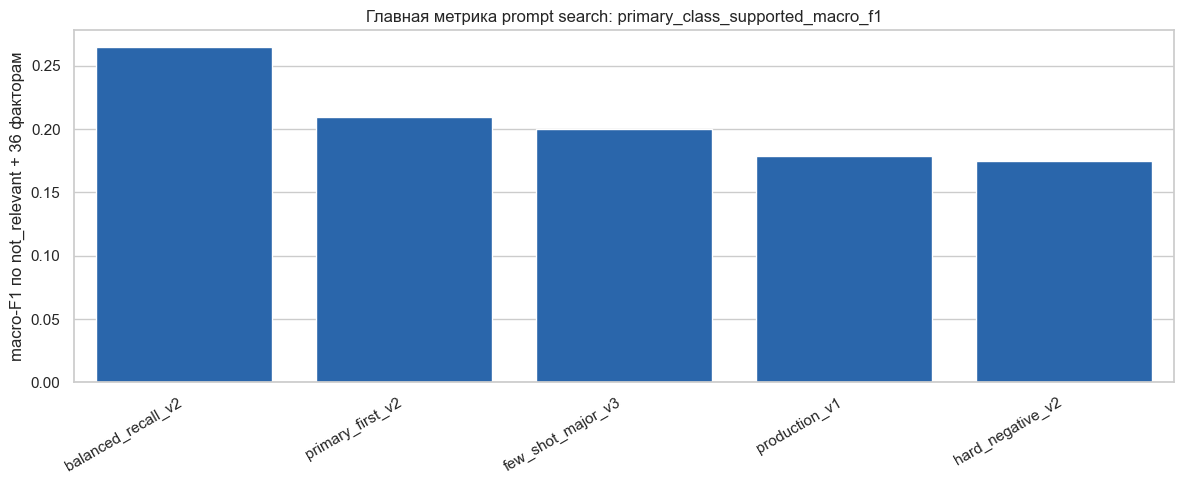

best_variant=balanced_recall_v2


In [6]:
search_rows = []
search_predictions = {}
for variant in PROMPT_VARIANTS:
    pred = classify_ids_with_variant(search_ids, variant, "search")
    search_predictions[variant["name"]] = pred
    row = evaluate_predictions(pred, search_ids, variant["name"], "search")
    search_rows.append(row)

search_results = pd.DataFrame(search_rows).sort_values("main_primary_class_supported_macro_f1", ascending=False)
display(compact_metric_table(search_results).round(4))

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=search_results,
    x="variant",
    y="main_primary_class_supported_macro_f1",
    ax=ax,
    color="#1565c0",
)
ax.set_title("Главная метрика prompt search: primary_class_supported_macro_f1")
ax.set_xlabel("")
ax.set_ylabel("macro-F1 по not_relevant + 36 факторам")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

best_variant_name = search_results.iloc[0]["variant"]
best_variant = next(item for item in PROMPT_VARIANTS if item["name"] == best_variant_name)
print(f"best_variant={best_variant_name}")

## 6. Полная оценка лучшего prompt на 1000 новостях

In [7]:
full_rows = []
# Production full уже есть из прошлого notebook; для честного сравнения добавим его всегда.
production_variant = next(item for item in PROMPT_VARIANTS if item["name"] == "production_v1")
production_full_pred = classify_ids_with_variant(full_ids, production_variant, "full")
full_rows.append(evaluate_predictions(production_full_pred, full_ids, "production_v1", "full"))

if best_variant_name != "production_v1":
    best_full_pred = classify_ids_with_variant(full_ids, best_variant, "full")
    full_rows.append(evaluate_predictions(best_full_pred, full_ids, best_variant_name, "full"))
else:
    best_full_pred = production_full_pred

full_results = pd.DataFrame(full_rows).sort_values("main_primary_class_supported_macro_f1", ascending=False)
display(compact_metric_table(full_results).round(4))

best_full_name = full_results.iloc[0]["variant"]
best_full_pred = production_full_pred if best_full_name == "production_v1" else best_full_pred

# Detailed report for the winning full prompt.
ranked = best_full_pred.sort_values(["dataset_row_id", "relevance"], ascending=[True, False])
top = ranked.groupby("dataset_row_id").first()[["factor_key", "relevance", "sentiment_label", "is_relevant"]]
any_rel = best_full_pred[best_full_pred["is_relevant"].astype(bool)].groupby("dataset_row_id").size().gt(0).rename("pred_any_relevant")
final_eval = df.set_index("dataset_row_id").join(top.add_prefix("top_")).join(any_rel)
final_eval["pred_any_relevant"] = final_eval["pred_any_relevant"].fillna(False).astype(bool)
final_eval["pred_primary_class"] = np.where(final_eval["pred_any_relevant"], final_eval["top_factor_key"], "not_relevant")

display(pd.DataFrame(classification_report(
    final_eval["manual_primary_class"],
    final_eval["pred_primary_class"],
    labels=class_labels,
    output_dict=True,
    zero_division=0,
)).T.sort_values("support", ascending=False).head(25).round(3))

display(pd.crosstab(final_eval["manual_applicable_bool"], final_eval["pred_any_relevant"], rownames=["manual_relevant"], colnames=["pred_relevant"]))

loaded production_v1 full: prompt_search_full_production_v1_gemma4-e2b_5df03950348d_b6a2d2f27b85.csv
loaded balanced_recall_v2 full: prompt_search_full_balanced_recall_v2_gemma4-e2b_5df03950348d_e98b1a3c5abc.csv


C:\Users\whynot\AppData\Local\Temp\ipykernel_34508\1756750786.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eval_frame["pred_any_relevant"] = eval_frame["pred_any_relevant"].fillna(False).astype(bool)
C:\Users\whynot\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\whynot\AppData\Local\Temp\ipykernel_34508\1756750786.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eval_frame["pred_any_releva

,variant,split,main_primary_class_supported_macro_f1,primary_class_macro_f1_all37,primary_class_head_macro_f1_support_ge_25,primary_class_weighted_f1,primary_class_accuracy,applicability_precision,applicability_recall_relevant,applicability_specificity_not_relevant,factor_micro_f1,true_factor_recall,signal_accuracy_when_true_factor_returned,predicted_relevant_news
1,balanced_recall_v2,full,0.2204,0.1251,0.3639,0.4488,0.473,0.8696,0.5793,0.7709,0.4327,0.3655,0.7396,483
0,production_v1,full,0.1681,0.0954,0.2467,0.3087,0.364,0.8864,0.3766,0.8727,0.2431,0.1710,0.8710,308


C:\Users\whynot\AppData\Local\Temp\ipykernel_34508\685009898.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_eval["pred_any_relevant"] = final_eval["pred_any_relevant"].fillna(False).astype(bool)


,precision,recall,f1-score,support
weighted avg,0.514,0.473,0.449,1000.000
macro avg,0.155,0.131,0.125,1000.000
not_relevant,0.410,0.771,0.535,275.000
crime_count,0.688,0.383,0.492,201.000
industrial_production_index,0.579,0.438,0.498,176.000
enterprises_count,0.746,0.331,0.458,133.000
consumer_price_index,0.467,0.648,0.543,54.000
air_pollution,0.875,0.250,0.389,28.000
mortality_rate,0.000,0.000,0.000,28.000
life_expectancy,0.000,0.000,0.000,26.000


pred_relevant,False,True
manual_relevant,,
False,212,63
True,305,420


## 7. Сохранение результатов и короткий вывод

In [8]:
output_paths = {
    "search_results": OUTPUT_DIR / "manual_dataset_prompt_search_results.csv",
    "full_results": OUTPUT_DIR / "manual_dataset_prompt_search_full_results.csv",
    "best_full_predictions": OUTPUT_DIR / f"manual_dataset_prompt_search_best_{best_full_name}.csv",
    "summary_json": OUTPUT_DIR / "manual_dataset_prompt_search_summary.json",
}
search_results.to_csv(output_paths["search_results"], index=False, encoding="utf-8")
full_results.to_csv(output_paths["full_results"], index=False, encoding="utf-8")
best_full_pred.to_csv(output_paths["best_full_predictions"], index=False, encoding="utf-8")

summary = {
    "main_metric": "primary_class_supported_macro_f1",
    "main_metric_definition": "single-label macro-F1 over supported classes from not_relevant + 36 primary factor classes",
    "search_sample_size": len(search_ids),
    "full_size": len(full_ids),
    "search_best_variant": best_variant_name,
    "full_best_variant": best_full_name,
    "full_best_main_primary_class_supported_macro_f1": float(full_results.iloc[0]["main_primary_class_supported_macro_f1"]),
    "full_best_primary_class_macro_f1_all37": float(full_results.iloc[0]["primary_class_macro_f1_all37"]),
    "full_best_primary_class_head_macro_f1_support_ge_25": float(full_results.iloc[0]["primary_class_head_macro_f1_support_ge_25"]),
    "full_best_primary_class_weighted_f1": float(full_results.iloc[0]["primary_class_weighted_f1"]),
    "full_best_applicability_precision": float(full_results.iloc[0]["applicability_precision"]),
    "full_best_applicability_recall_relevant": float(full_results.iloc[0]["applicability_recall_relevant"]),
    "full_best_applicability_specificity_not_relevant": float(full_results.iloc[0]["applicability_specificity_not_relevant"]),
    "full_best_factor_micro_f1": float(full_results.iloc[0]["factor_micro_f1"]),
    "full_best_true_factor_recall": float(full_results.iloc[0]["true_factor_recall"]),
    "full_best_signal_accuracy_when_true_factor_returned": float(full_results.iloc[0]["signal_accuracy_when_true_factor_returned"]),
    "output_paths": {key: str(value) for key, value in output_paths.items()},
}
output_paths["summary_json"].write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")

display(Markdown(f'''
## Итоговое табло

Главная метрика: `primary_class_supported_macro_f1`.

Лучший prompt на search sample: `{best_variant_name}`.

Лучший prompt на полном датасете: `{best_full_name}`.

Full `primary_class_supported_macro_f1`: **{summary['full_best_main_primary_class_supported_macro_f1']:.3f}**.

Full strict `macro_f1_all37`: **{summary['full_best_primary_class_macro_f1_all37']:.3f}**.

Full head-class `macro_f1_support>=25`: **{summary['full_best_primary_class_head_macro_f1_support_ge_25']:.3f}**.

Full `weighted_f1`: **{summary['full_best_primary_class_weighted_f1']:.3f}**.

Full `factor_micro_f1`: **{summary['full_best_factor_micro_f1']:.3f}**.

Full `not_relevant specificity`: **{summary['full_best_applicability_specificity_not_relevant']:.3f}**.

Full `relevant recall`: **{summary['full_best_applicability_recall_relevant']:.3f}**.
'''))

print("Saved artifacts:")
for key, value in output_paths.items():
    print(f"- {key}: {value}")


## Итоговое табло

Главная метрика: `primary_class_supported_macro_f1`.

Лучший prompt на search sample: `balanced_recall_v2`.

Лучший prompt на полном датасете: `balanced_recall_v2`.

Full `primary_class_supported_macro_f1`: **0.220**.

Full strict `macro_f1_all37`: **0.125**.

Full head-class `macro_f1_support>=25`: **0.364**.

Full `weighted_f1`: **0.449**.

Full `factor_micro_f1`: **0.433**.

Full `not_relevant specificity`: **0.771**.

Full `relevant recall`: **0.579**.


Saved artifacts:
- search_results: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_prompt_search_results.csv
- full_results: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_prompt_search_full_results.csv
- best_full_predictions: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_prompt_search_best_balanced_recall_v2.csv
- summary_json: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_prompt_search_summary.json
